In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# step 1: Load the dataset from a CSV file
url = 'https://raw.githubusercontent.com/kanetkar/LULML/refs/heads/main/ch12/students.csv'
df = pd.read_csv(url)

# step 2: Define the input features (X) and the target variable (y)
X = df[['IQ', 'CGPA']]
y = df['Placed']

# step 3: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,
	random_state = 42)

# step 4: Initialize and train the Logistic Regression model
model = LogisticRegression( )
model.fit(X_train, y_train)

# step 5: Use the trained model to make predictions on the test data
y_pred = model.predict(X_test)

# step 6: Calculate accuracy by comparing predicted and actual labels
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.95


In [ ]:
# import required metrics from scikit-learn
from sklearn.metrics import precision_score, recall_score, f1_score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(precision, recall, f1)

0.9285714285714286 1.0 0.9629629629629629


In [2]:
model = LogisticRegression( )
model.fit(X_train, y_train)

# predict probabilities, not hard classes
y_pred_proba = model.predict_proba(X_test)[:, 1]
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"ROC-AUC Score: {auc_score:.2f}")

ROC-AUC Score: 1.00


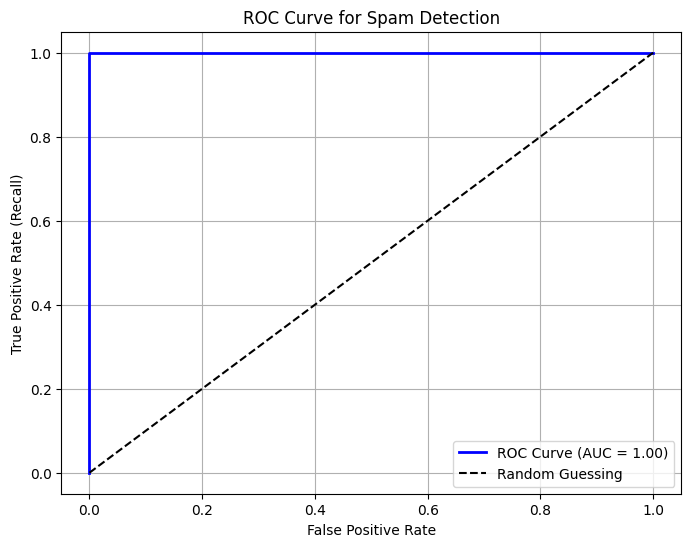

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')

plt.title('ROC Curve for Spam Detection')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()